In [1]:
import sys
from pathlib import Path

# Get the notebook's directory as a Path object
notebook_dir = Path.cwd() # .cwd() gets the Current Working Directory

# Go up TWO levels
project_root = notebook_dir.parent.parent

# Add the project root (as a string) to the system path
project_root_str = str(project_root)
if project_root_str not in sys.path:
    sys.path.append(project_root_str)

print(project_root_str)

/home/manosgior/Documents/GitHub/MCMit


In [2]:
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister
from ConstantPropagation import ConstantPropagation
from qiskit.circuit.classical import expr

from applications.quantum_teleportation import *
from applications.constant_depth_GHZ import *
from applications.long_range_CNOT import *

## Test cases

In [ ]:
def one_mid_meas_pure_state():
    qr = QuantumRegister(3, 'q')
    cr = ClassicalRegister(3, 'c')
    qc = QuantumCircuit(qr, cr)

    qc.h(qr[0])
    qc.measure(qr[0], cr[0])
    with qc.if_test((cr[0], 1)):
        qc.z(qr[2])

    return qc

def one_mid_meas_mixed_state():
    qr = QuantumRegister(3, 'q')
    cr = ClassicalRegister(3, 'c')
    qc = QuantumCircuit(qr, cr)

    qc.h(qr[0])
    qc.cx(qr[0], cr[0])
    qc.measure(qr[0], cr[0])
    with qc.if_test((cr[0], 1)):
        qc.z(qr[2])

    return qc


def reset_pure_state():
    qr = QuantumRegister(3, 'q')
    cr = ClassicalRegister(3, 'c')
    qc = QuantumCircuit(qr, cr)

    qc.h(qr[0])
    qc.measure(qr[0], cr[0])
    with qc.if_test((cr[0], 1)):
        qc.z(qr[2])
    qc.reset(qr[0])
    qc.x(qr[0])
    qc.measure(qr[0], cr[0])
    with qc.if_test((cr[0], 1)):
        qc.z(qr[2])

    return qc

def mid_meas_whole_reg_true():
    qr = QuantumRegister(3, 'q')
    cr = ClassicalRegister(3, 'c')
    qc = QuantumCircuit(qr, cr)

    qc.x(qr[0])
    qc.x(qr[1])

    qc.measure(qr, cr) # cr = 3
    with qc.if_test((cr, 4)):
        qc.z(qr[2])

    return qc

def mid_meas_whole_reg_false():
    qr = QuantumRegister(3, 'q')
    cr = ClassicalRegister(3, 'c')
    qc = QuantumCircuit(qr, cr)


    qc.x(qr[0])
    qc.x(qr[2])

    qc.measure(qr, cr)
    with qc.if_test((cr, 3)):
        qc.z(qr[2])

    return qc

## TP Circuit

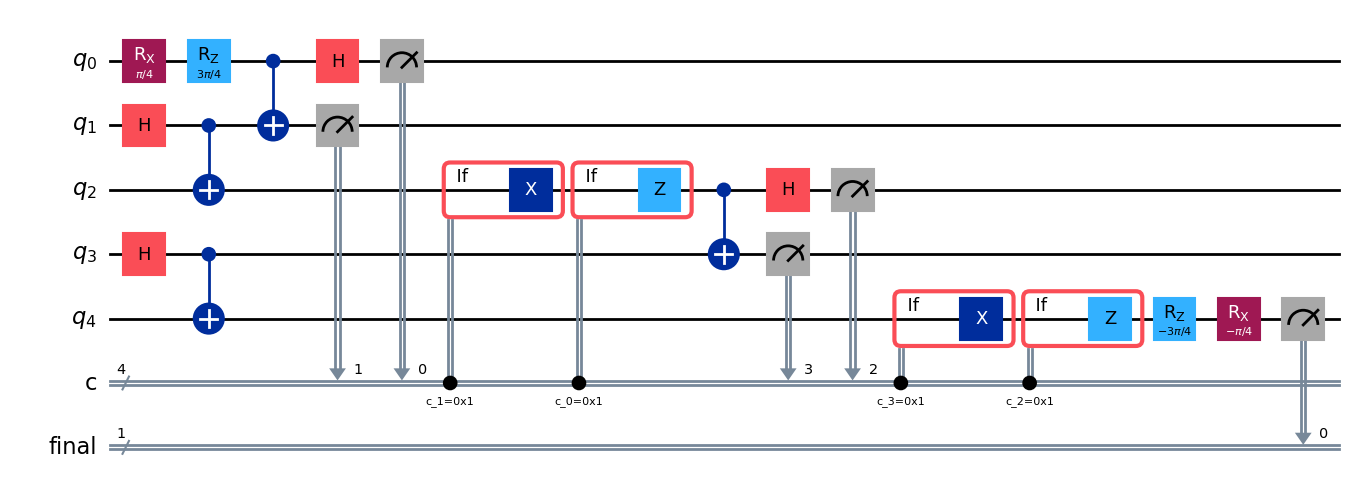

In [4]:
#tp_circ = create_teleportation_circuit()
tp_circ = create_ladder_teleportation_circuit(2)
tp_circ.draw('mpl')

## GHZ state circuit

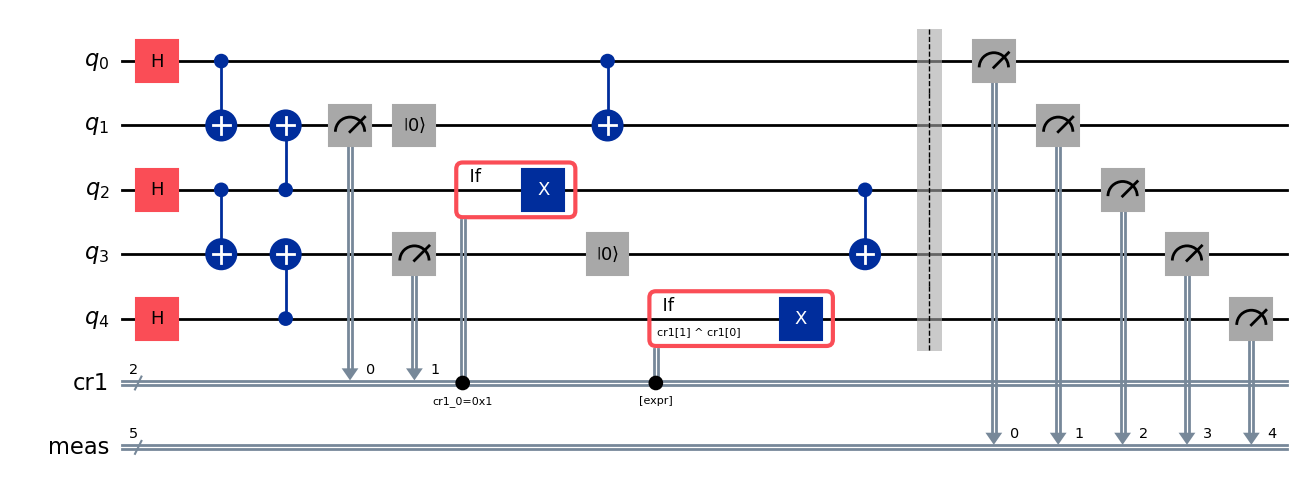

In [5]:
ghz_circuit = create_constant_depth_ghz(5)
ghz_circuit.draw('mpl')

## Long-range CNOT circuit

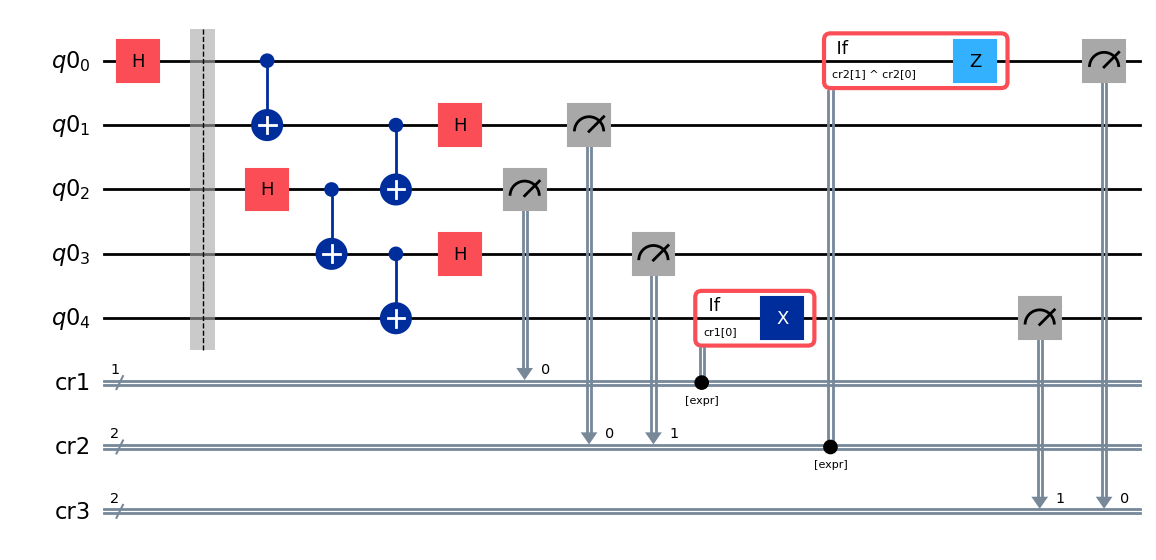

In [6]:
long_cnot = create_dynamic_CNOT_circuit(5)
long_cnot.draw('mpl')

## Optimised circuit

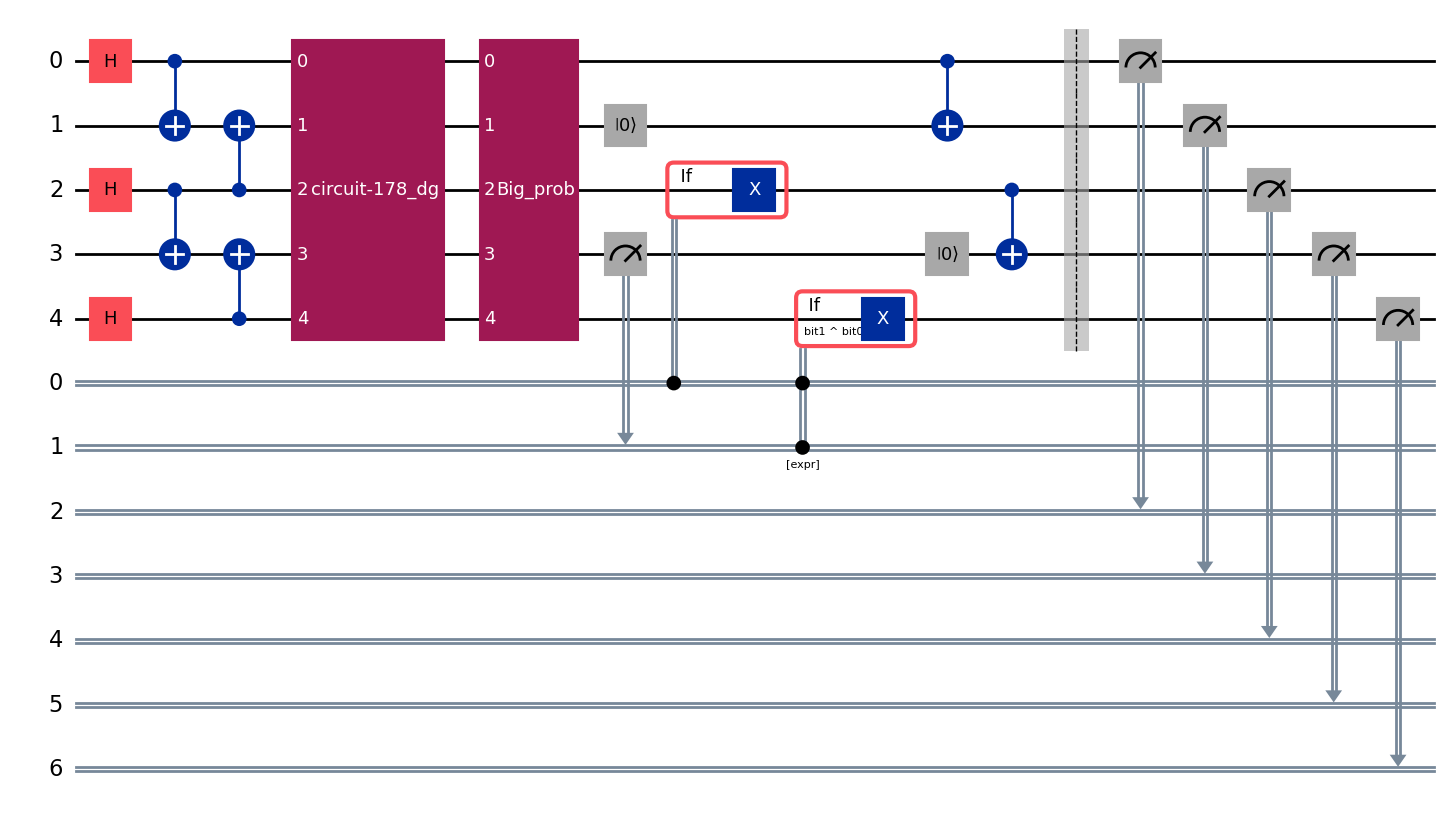

In [7]:
table, qc_opt = ConstantPropagation.optimize(ghz_circuit, max_ent_group_size = 5)
qc_opt.draw('mpl')

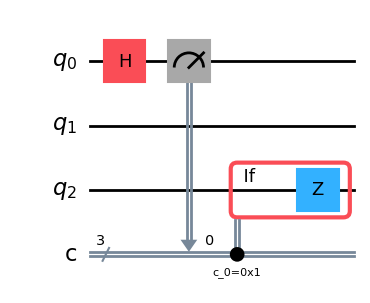

In [9]:
simple = one_mid_meas_pure_state()
simple.draw('mpl')

In [10]:
table, qc_opt = ConstantPropagation.optimize(simple, max_ent_group_size = 5)
qc_opt.draw('mpl')

TypeError: 'NoneType' object is not iterable

## Instance

In [8]:
instance = ConstantPropagation.generate_istance(qc_opt)
#instance.draw('mpl')

TypeError: 'NoneType' object is not iterable